In [1]:
%matplotlib widget
import os
import copy
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib
from dataclasses import dataclass, field

# ============================================================
# 1. STYLE & OBJECT CONFIGURATION
# ============================================================
@dataclass
class Spectrum:
    N: str                      # Nombre o Label
    X: np.ndarray               # Wavelength (nm)
    Y: np.ndarray               # Absorbance / Intensity
    wcorr: float = 0.0          # Factor de corrección de agua por defecto
    color: str = None           # Color para ploteo
    linestyle: str = None       # Estilo de línea
    
    def copy(self):
        """Devuelve una copia profunda del espectro conservando sus propiedades"""
        return Spectrum(
            N=self.N, 
            X=self.X.copy(), 
            Y=self.Y.copy(), 
            wcorr=self.wcorr, 
            color=self.color,         
            linestyle=self.linestyle  
        )


poster_style = {
    "figsize": (4,6),
    "dpi": 300,
    "font_size": 10,
    "title_size": 12,
    "label_size": 12,
    "legend_size": 8,
    "line_width": 2,
    "font_family": "Calibri",
    "grid": True,               
    "colors": ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#56B4E9", "#D55E00", "#F0E442"], 
    "linestyles": ["-", "--", "-.", ":"]
}

# ============================================================
# 2. CORE FUNCTIONS
# ============================================================
def PlotSpectra(
        spectra_list, mode="W", style=poster_style, offset_step=0.0,
        xmin=None, xmax=None, ymin=None, ymax=None, 
        xlabel_W="Wavelength (nm)", xlabel_E="Energy (eV)", ylabel="Absorbance",
        custom_colors=None, custom_linestyles=None, 
        vlines=None,  # <--- NUEVO PARÁMETRO AQUÍ
        hide_yticks=False, save_path=None, legend_ncol=1
):
    fig, ax1 = plt.subplots(figsize=style["figsize"], dpi=style["dpi"])
    plt.rcParams.update({"font.size": style["font_size"], "font.family": style["font_family"]})
    
    # ... (todo el código de colores y ploteo de las curvas se queda igual) ...
    default_colors = style.get("colors") or ["#000000"]
    default_linestyles = style.get("linestyles") or ["-"]
    
    for i, s in enumerate(spectra_list):
        y_offset = s.Y + (i * offset_step)
        c = getattr(s, 'color', None) or (custom_colors[i] if custom_colors and i < len(custom_colors) else default_colors[i % len(default_colors)])
        ls = getattr(s, 'linestyle', None) or (custom_linestyles[i] if custom_linestyles and i < len(custom_linestyles) else default_linestyles[i % len(default_linestyles)])

        if mode in ["W", "WE"]:
            ax1.plot(s.X, y_offset, label=s.N, linewidth=style["line_width"], color=c, linestyle=ls)
            ax1.set_xlabel(xlabel_W, fontsize=style["label_size"])
        elif mode in ["E", "EW"]:
            E_array = np.divide(1240.0, s.X, out=np.zeros_like(s.X), where=s.X != 0)
            ax1.plot(E_array, y_offset, label=s.N, linewidth=style["line_width"], color=c, linestyle=ls)
            ax1.set_xlabel(xlabel_E, fontsize=style["label_size"])

    ax1.set_ylabel(ylabel, fontsize=style["label_size"])
    
    if xmin is not None or xmax is not None: ax1.set_xlim(xmin, xmax)
    if ymin is not None or ymax is not None: ax1.set_ylim(ymin, ymax)
    if style.get("grid", False): ax1.grid(True, alpha=0.3)
    if hide_yticks: ax1.set_yticklabels([])

    if mode in ["WE", "EW"]:
        def forward(x):
            with np.errstate(divide='ignore', invalid='ignore'):
                return np.where(x == 0, np.inf, 1240.0 / x)
        def inverse(x):
            with np.errstate(divide='ignore', invalid='ignore'):
                return np.where(x == 0, np.inf, 1240.0 / x)

        if mode == "WE":
            ax2 = ax1.secondary_xaxis('top', functions=(forward, inverse))
            ax2.set_xlabel(xlabel_E, fontsize=style["label_size"])
        elif mode == "EW":
            ax2 = ax1.secondary_xaxis('top', functions=(inverse, forward))
            ax2.set_xlabel(xlabel_W, fontsize=style["label_size"])

    # ==========================================================
    # NUEVO: DIBUJAR LÍNEAS VERTICALES ANTES DEL SHOW()
    # ==========================================================
    if vlines is not None:
        for x_val in vlines:
            # Si el eje principal es Energía, convierte el nm a eV para plotearlo
            pos = (1240.0 / x_val) if mode in ["E", "EW"] else x_val
            ax1.axvline(x=pos, linewidth=0.5, linestyle='--', color='black', alpha=0.7, zorder=0)
    ax1.legend(fontsize=style["legend_size"], ncol=legend_ncol)
    plt.tight_layout()
    plt.show()

def SubtractBaseline(spectra_list, baseline_obj):
    res = []
    for s in spectra_list:
        new_s = s.copy()
        base_interp = np.interp(new_s.X, baseline_obj.X, baseline_obj.Y)
        new_s.Y = new_s.Y - base_interp
        res.append(new_s)
    return res

def ApplyCalibrationCorrection(spectra_list, calibration_obj):
    """
    Aplica la corrección de agua usando s.wcorr definido en cada espectro.
    """
    res = []
    for s in spectra_list:
        new_s = s.copy()
        cal_interp = np.interp(new_s.X, calibration_obj.X, calibration_obj.Y)
        new_s.Y = new_s.Y - (new_s.wcorr * cal_interp)
        res.append(new_s)
    return res

def TrimSpectra(spectra_input, xmin=None, xmax=None):
    """
    Recorta uno o varios espectros a un rango de Wavelength.
    Funciona tanto si pasas una lista de Spectrum como un único objeto Spectrum.
    """
    # Si pasamos un único objeto Spectrum en lugar de una lista:
    if isinstance(spectra_input, Spectrum):
        new_s = spectra_input.copy()
        mask = np.ones_like(new_s.X, dtype=bool)
        if xmin is not None: mask &= (new_s.X >= xmin)
        if xmax is not None: mask &= (new_s.X <= xmax)
        
        if not np.any(mask):
            print(f"Warning: empty trim range for {new_s.N}")
            return new_s
            
        new_s.X = new_s.X[mask]
        new_s.Y = new_s.Y[mask]
        return new_s

    # Si pasamos una lista (comportamiento habitual del pipeline):
    res = []
    for s in spectra_input:
        new_s = s.copy()
        mask = np.ones_like(new_s.X, dtype=bool)
        if xmin is not None: mask &= (new_s.X >= xmin)
        if xmax is not None: mask &= (new_s.X <= xmax)
        
        if not np.any(mask):
            print(f"Warning: empty trim range for {new_s.N}")
            continue
            
        new_s.X = new_s.X[mask]
        new_s.Y = new_s.Y[mask]
        res.append(new_s)
    return res

def BackgroundCorrection(spectra_list, a, b):
    res = []
    for s in spectra_list:
        new_s = s.copy()
        current_a = a.get(new_s.N, 0.0) if isinstance(a, dict) else a
        current_b = b.get(new_s.N, 0.0) if isinstance(b, dict) else b
        new_s.Y = new_s.Y - ((current_a / new_s.X) + current_b)
        res.append(new_s)
    return res

def NormalizeSpectra(spectra_list, xmin, xmax, mode="M"):
    res = []
    for s in spectra_list:
        new_s = s.copy()
        mask = (new_s.X >= xmin) & (new_s.X <= xmax)
        X_win, Y_win = new_s.X[mask], new_s.Y[mask]
        if len(X_win) == 0: continue
        
        if mode.upper() == "M": factor = np.max(Y_win)
        elif mode.upper() == "I": factor = np.trapezoid(Y_win, X_win)
        elif mode.upper() == "V": factor = np.min(Y_win)
        else: raise ValueError("Invalid mode")
        
        if factor == 0: continue
        new_s.Y = new_s.Y / factor
        res.append(new_s)
    return res

def rename(spectra_list, new_names):
    """Reemplaza el atributo .N de cada espectro en orden."""
    for s, name in zip(spectra_list, new_names):
        s.N = name
    return spectra_list

# ============================================================
# 3. LOAD DATA & CREATE VARIABLES
# ============================================================
References = r"H:\FUBerlin\Measurements\UVvisNIR\References.csv"
try:
    calibration_df = pd.read_csv(
        References, sep=",", skiprows=2, header=None,
        names=["Water_Wavelength", "WaterInD2O", "Nicodenz_Wavelength", "Nicodenz",
               "Empty_Wavelength", "Empty_P2", "WaterFilled_Wavelength", "WaterFilled"]
    )
    cal_objects = {}
    for i in range(0, len(calibration_df.columns), 2):
        w_col = calibration_df.columns[i]
        a_col = calibration_df.columns[i + 1]
        df_temp = pd.DataFrame({"X": pd.to_numeric(calibration_df[w_col], errors="coerce"),
                                "Y": pd.to_numeric(calibration_df[a_col], errors="coerce")}).dropna().sort_values("X")
        cal_objects[a_col] = Spectrum(N=a_col, X=df_temp["X"].values, Y=df_temp["Y"].values)
    water_calibration = cal_objects["WaterInD2O"]
except Exception as e:
    print(f"Warning: Could not load calibration data: {e}")

txt_folders = [
    r"H:\FUBerlin\Measurements\UVvisNIR\CristianB\20260810_DGUdial_P2_F005_F006_F007",
    r"H:\FUBerlin\Measurements\UVvisNIR\CristianB\20260817_DGUdial_P2_F005_F006_F007_ProperResolution",
]

print("Loading Experimental Spectra...")
for folder in txt_folders:
    if not os.path.exists(folder): continue
    for file in os.listdir(folder):
        if not file.lower().endswith(".txt"): continue
        if "readme" in file.lower(): continue  
        path = os.path.join(folder, file)
        try:
            df = pd.read_csv(path, sep="\t", skiprows=1, dtype=str)
            df.columns = ["W", "A"]
            df["W"] = pd.to_numeric(df["W"].str.strip().str.replace(",", ".", regex=False), errors="coerce")
            df["A"] = pd.to_numeric(df["A"].str.strip().str.replace(",", ".", regex=False), errors="coerce")
            df = df.dropna().sort_values("W")
            
            var_name = "S" + file.replace(".txt", "").replace("@", "_").replace("-", "_").replace(" ", "_")
            globals()[var_name] = Spectrum(N=var_name, X=df["W"].values, Y=df["A"].values)
        except Exception as e:
            pass

try:
    baseline = S20260817_Baseline_DOCD2O1pc
except NameError:
    print("Warning: Baseline file not found in folders.")


Loading Experimental Spectra...


In [2]:
from scipy.signal import find_peaks

def FindExtrema(spectrum, mode="minima", distance=15, prominence=0.01, xmin=None, xmax=None):
    """
    Detecta picos o valles reales dentro de un rango específico [xmin, xmax].
    """
    X = np.array(spectrum.X)
    Y = np.array(spectrum.Y)
    
    # 1. Crear una máscara para recortar el rango de búsqueda
    mask = np.ones_like(X, dtype=bool)
    if xmin is not None:
        mask &= (X >= xmin)
    if xmax is not None:
        mask &= (X <= xmax)
        
    X_sub = X[mask]
    Y_sub = Y[mask]
    
    if len(X_sub) == 0:
        print("Warning: El rango de búsqueda [xmin, xmax] está vacío.")
        return []
    
    # 2. Invertir señal si buscamos mínimos (valles)
    signal = -Y_sub if mode.lower() == "minima" else Y_sub
    
    # 3. Buscar picos solo en esa sección limpia
    peaks_sub, _ = find_peaks(signal, distance=distance, prominence=prominence)
    
    print(f"\n--- Extremos ({mode.upper()}) en rango [{xmin} - {xmax} nm] para: {spectrum.N} ---")
    print(f"{'#':<4} | {'Wavelength (nm)':<16} | {'Intensity (Y)':<12}")
    print("-" * 40)
    
    orig_indices = []
    for i, idx in enumerate(peaks_sub):
        # Mapear el índice de la subregión al array original
        orig_idx = np.where(mask)[0][idx]
        orig_indices.append(orig_idx)
        
        x_val = X[orig_idx]
        y_val = Y[orig_idx]
        print(f"{i:<4} | {x_val:<16.2f} | {y_val:<12.4f}")
        
    print("-" * 40)
    return orig_indices

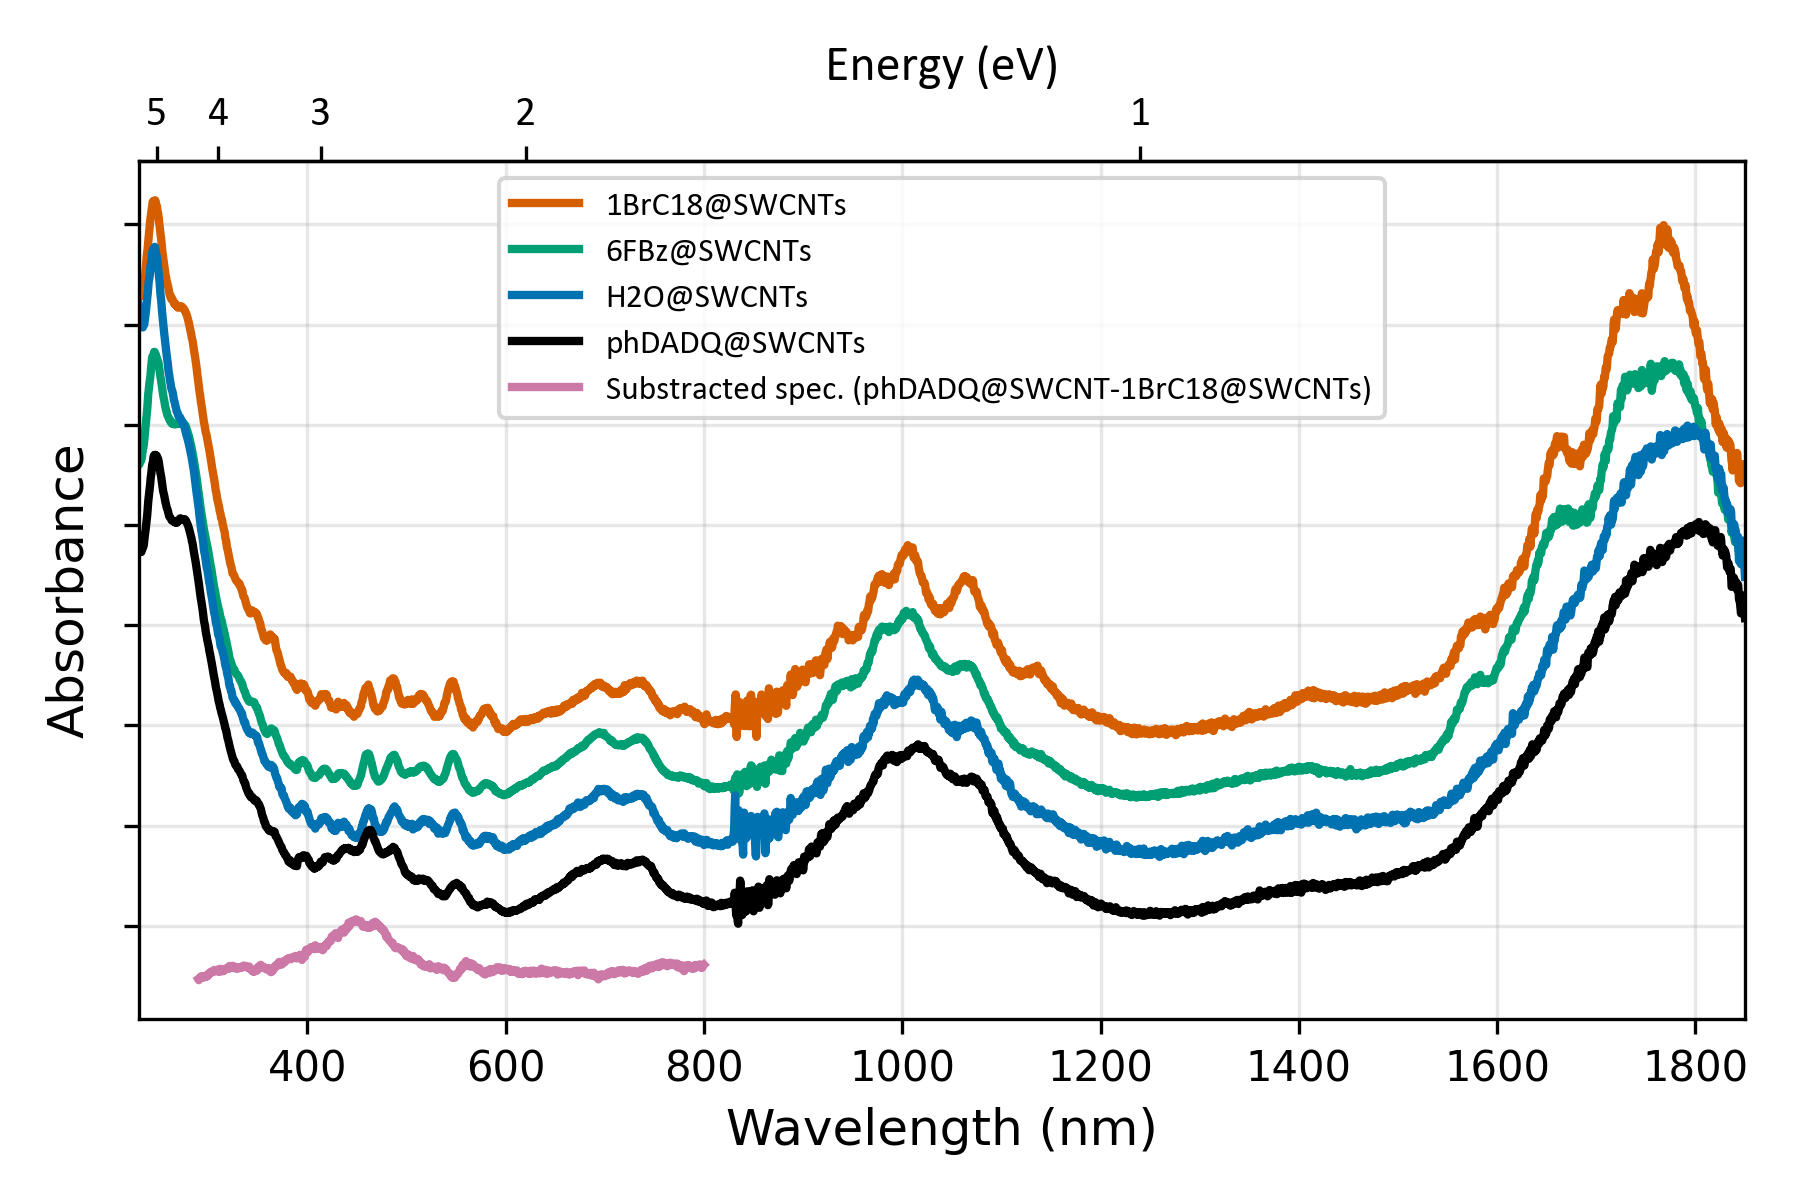

In [3]:
# ============================================================
# 4. SELECTION, PIPELINE & PLOTTING
# ============================================================

# 1. Define tu configuración maestra aquí (¡Cualquier cambio aquí se aplicará al instante!)
spectra_config = [
    # (Variable, Nombre, wcorr, Color, Linestyle)
    (S20260817_F007WA_1BrC18_P2_DGUdial, "1BrC18@SWCNTs", 0.2, "#D55E00", "-"),
    (S20260817_F005LP_6FBz_P2_DGUdial,   "6FBz@SWCNTs",   1.5, "#009E73", "-"),
    (S20260817_P2_DGUdial,               "H2O@SWCNTs",    0.0, "#0072B2", "-"),
    (S20260817_F006WA_phDADQ_P2_DGUdial, "phDADQ@SWCNTs",  0.3, "#000000", "-"),

]

# 2. Construcción fresca de la lista Selection
Selection = []
for var, name, factor, col, ls in spectra_config:
    s = var.copy()
    s.N = name
    s.wcorr = factor
    s.color = col
    s.linestyle = ls
    Selection.append(s)

# --- PIPELINE DE CORRECCIÓN ---
# (Nota: Asegúrate de que tus funciones de procesamiento usen s.copy() 
# propagando s.color y s.linestyle. Si no lo hacen, los pierden en el camino).
Selection = SubtractBaseline(Selection, baseline)
Selection = ApplyCalibrationCorrection(Selection, water_calibration) 
Selection = NormalizeSpectra(Selection, xmin=1200, xmax=1350, mode="V")
Selection = TrimSpectra(Selection, xmin=228, xmax=1850)
Selection = BackgroundCorrection(Selection, a=1400, b=0)


if 1==1:
    Substracted = Selection[3].copy()
    Substracted.N = "Substracted spec. (phDADQ@SWCNT-1BrC18@SWCNTs)"  # Dale un nombre limpio para la leyenda
    Substracted.color = "#CC79A7"               # Un color distintivo para la resta

    # Restamos los arrays Y
    additionalOffset = 0
    Substracted.Y = Selection[3].Y - Selection[2].Y - additionalOffset
    Substracted = TrimSpectra(Substracted, xmin=290, xmax=800)

    # Lo agregamos a la lista que vamos a graficar
    Selection.append(Substracted)

# --- GRAFICAR ---
    
poster_style = {
    "figsize": (6,4),
    "dpi": 300,
    "font_size": 10,
    "title_size": 12,
    "label_size": 12,
    "legend_size": 8,
    "line_width": 2,
    "font_family": "Calibri",
    "grid": True,               
    "colors": ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#56B4E9", "#D55E00", "#F0E442"], 
    "linestyles": ["-", "--", "-.", ":"]
}


PlotSpectra(
    spectra_list=Selection,
    mode="WE",
    offset_step=-0.6,
    ylabel="Absorbance",
    hide_yticks=True,
    xmax=1850,
    xmin=230,
    style=poster_style,
    )



#picos = [418, 461.50, 486, 514.0, 545.5, 582, 935, 979.5, 1005.5, 1063, 1136.5]
picos = [935,979,1005,1063,1136,1583,1660,1727,1768]

for xi in picos: 
    # Usamos ax1.axvline en lugar de plt.axvline
    plt.axvline(x=xi, linewidth=0.5, linestyle='--', color='black', alpha=0.7, zorder=0)

#Peaks = FindExtrema(Selection[0], mode="maxima", distance=10, prominence=0.1, xmin=900, xmax=1840)



In [4]:
# ============================================================
# NEW CELL: Load Older CSV Spectra via spectra.io
# ============================================================
import sys
import os
import numpy as np

# Add the root folder (where 'spectra' lives) to sys.path with top priority
ROOT = r"H:\FUBerlin\DataAnalysis"
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from spectra.io import load_absorption_csv  # now Python can find it

# === PROJECT AND DATA FOLDER ===
data_folders = [
    r'H:\FUBerlin\Measurements\UVVis\CristianB\20260804_PLE_PostDial_P2_F005LP_F006_F007_NI',
    r'H:\FUBerlin\Measurements\UVVis\CristianB\20260803_PostDial_P2_F005LP_F006_F007',
    r'H:\FUBerlin\Measurements\UVVis\CristianB\20260731_DGU_D2OBased_P2_F005LP_F006_F007',
    r'H:\FUBerlin\Measurements\UVVis\CristianB\20260618_phDADQ_DMF_dilutionsNoBL',
    r'H:\FUBerlin\Measurements\UVVis\CristianB\20260618_F006_phDADQ@P2_Solubilized',
    r'H:\FUBerlin\Measurements\UVVis\CristianB\20260528_F006_phDADQ@P2_DMF_WashingSteps',


]

# === LOAD ALL CSV FILES IN THE FOLDERS ===
spectra_dict = {}

for data_folder in data_folders:
    if os.path.exists(data_folder):
        for file in os.listdir(data_folder):
            if file.lower().endswith(".csv"):
                csv_path = os.path.join(data_folder, file)
                try:
                    spectra = load_absorption_csv(csv_path)
                    for s in spectra:
                        spectra_dict[s.N] = s
                except Exception as e:
                    print(f"Error loading CSV {file}: {e}")
    else:
        print(f"Warning: Folder not found: {data_folder}")

print(f"\nLoaded {len(spectra_dict)} spectra into `spectra_dict`:")
#for name in sorted(spectra_dict.keys()):
#    print(f"  - {name}")

# === OPTIONAL BRIDGE ===
# Automatically registers them as global Spectrum objects (e.g., SP2_d5) 
# so your modern script's `spectra_config` can pick them up instantly.
for name, s in spectra_dict.items():
    var_name = "S" + str(name).replace(".", "_").replace("@", "_").replace("-", "_").replace(" ", "_")
    try:
        globals()[var_name] = Spectrum(
            N=s.N,
            X=np.array(s.X, dtype=float),
            Y=np.array(s.Y, dtype=float),
            wcorr=0.0
        )
        print(f"{var_name}")

    except NameError:
        pass # Ignored if the Spectrum class isn't defined yet in this notebook order


Loaded 39 spectra into `spectra_dict`:
S20260804_F007WA_1BrC18_P2_DGUdial
S20260804_P2_DGUdial
S20260804_F005LP_6FBz_P2_DGUdial
S20260804_F006WA_phDADQ_P2_DGUdial
S20260803_P2_DGUdial
S20260803_F005LP_6FBz_P2_DGUdial
S20260803_F007WA_1BrC18_P2_DGUdial
S20260803_F006WA_phDADQ_P2_DGUdial
S20260731_P2_DGU_B_d1
S20260731_P2_DGU_C_d1
S20260731_P2_DGU_D_d1
S20260731_P2_DGU_D_d4
S20260731_F005LP_6FBz_P2_DGU_B_d1
S20260731_F005LP_6FBz_P2_DGU_C_d1
S20260731_F005LP_6FBz_P2_DGU_D_d1
S20260731_F005LP_6FBz_P2_DGU_D_d4
S20260731_F006WA_phDADQ_P2_DGU_B_d1
S20260731_F006WA_phDADQ_P2_DGU_C_d1
S20260731_F006WA_phDADQ_P2_DGU_D_d1
S20260731_F006WA_phDADQ_P2_DGU_D_d4
S20260731_F007WA_1BrC18_P2_DGU_B_d1
S20260731_F007WA_1BrC18_P2_DGU_C_d1
S20260731_F007WA_1BrC18_P2_DGU_D_d1
S20260731_F007WA_1BrC18_P2_DGU_D_d4
SphDADQ_DMF_10
SphDADQ_DMF_20
SphDADQ_DMF_50
SphDADQ_DMF_70
SphDADQ_DMF_100
SphDADQ_DMF_200
SF006WA_phDADQ_P2_CF_260605_usedForPLE
SF006WA_phDADQ_P2_CF_260605_darker_d2
SP2_SWCNT_CF_usedForPLE
SF006_R

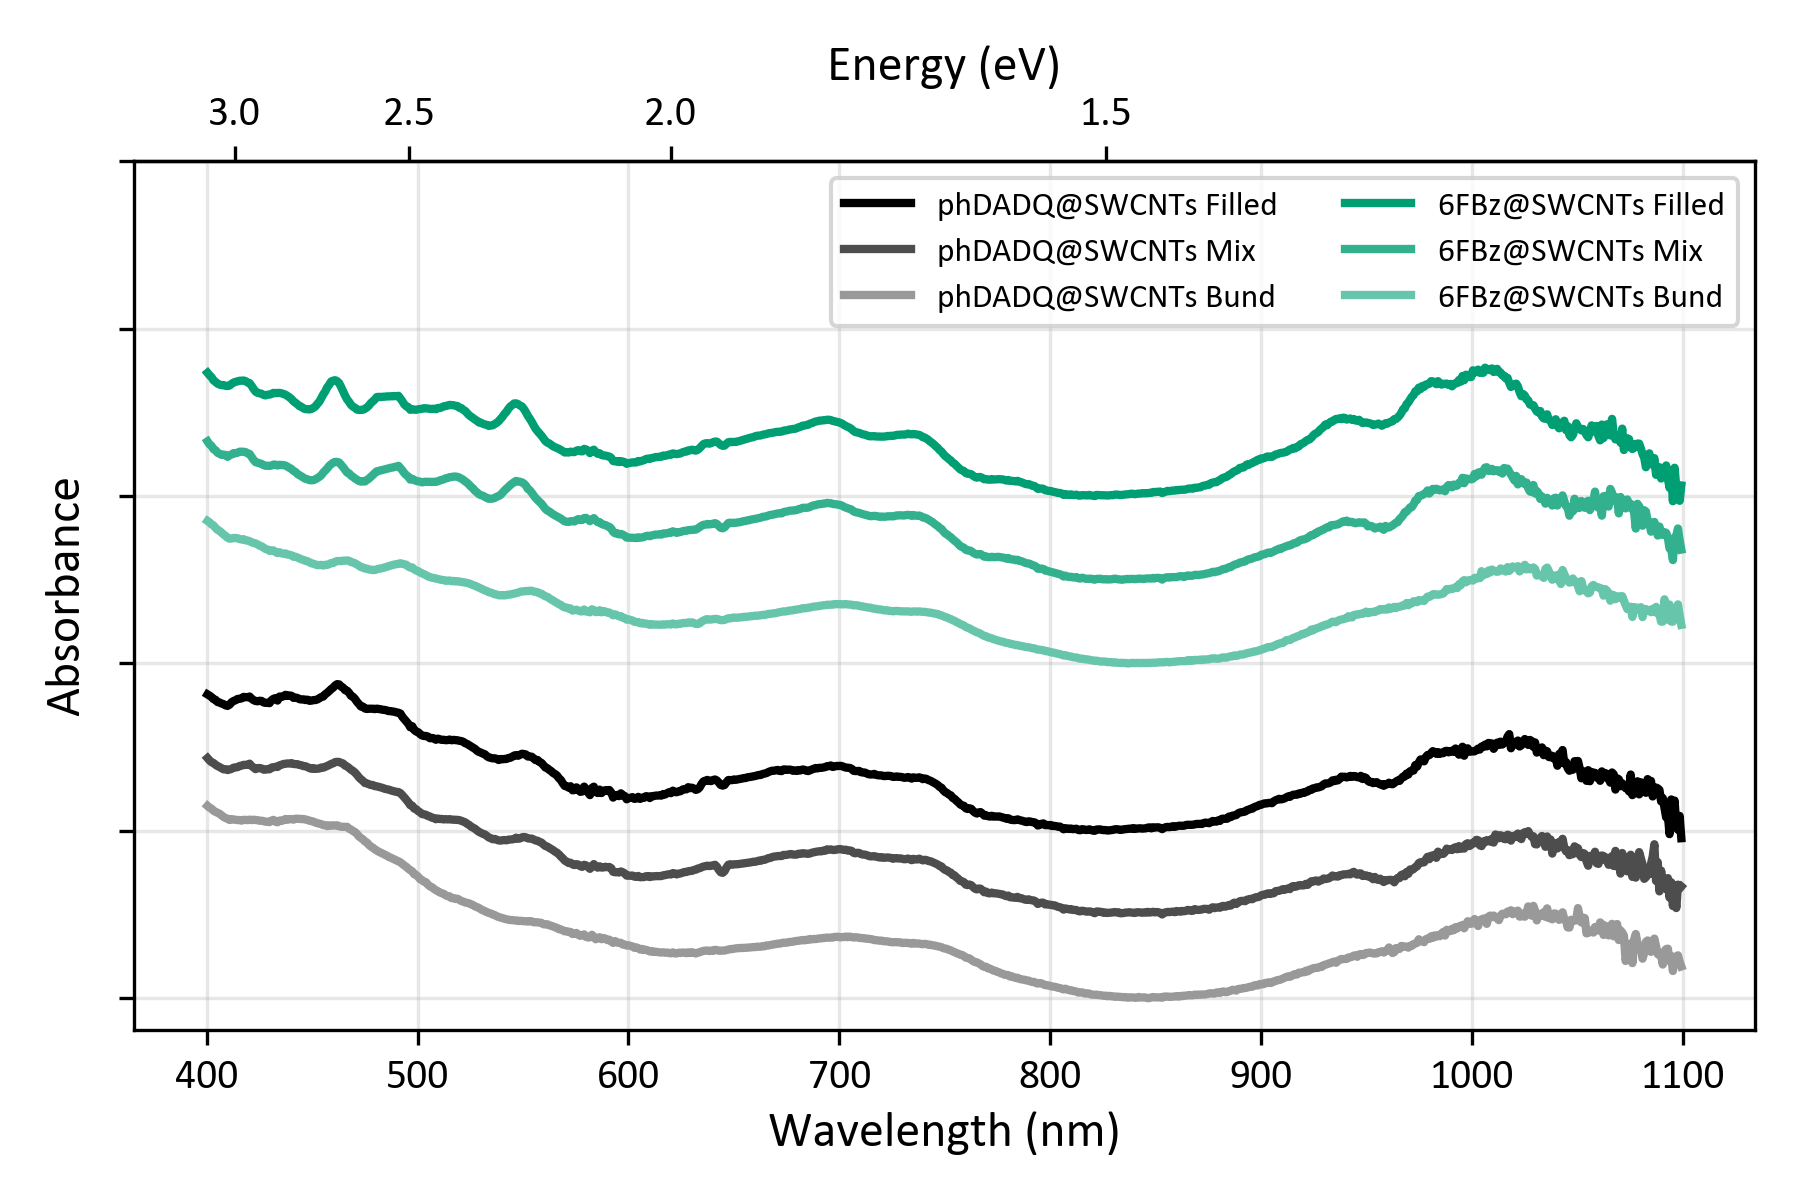

In [5]:
spectra_config = [
    # (Variable, Nombre, wcorr, Color, Linestyle)
    (S20260731_F006WA_phDADQ_P2_DGU_B_d1, "phDADQ@SWCNTs Filled", 0.0, "#000000", "-"),
    (S20260731_F006WA_phDADQ_P2_DGU_C_d1, "phDADQ@SWCNTs Mix", 0.0, "#4D4D4D", "-"),
    (S20260731_F006WA_phDADQ_P2_DGU_D_d4, "phDADQ@SWCNTs Bund",  0.0, "#999999", "-"),

    #(S20260731_F007WA_1BrC18_P2_DGU_D_d4, "1BrC18@P2",  0.0, "#D55E00", "-"),
    #(S20260731_F007WA_1BrC18_P2_DGU_C_d1, "1BrC18@P2", 0.0, "#D55E00", "-"),
    #(S20260731_F007WA_1BrC18_P2_DGU_B_d1, "1BrC18@P2", 0.0, "#D55E00", "-"),

    (S20260731_F005LP_6FBz_P2_DGU_B_d1, "6FBz@SWCNTs Filled", 0.0, "#009E73", "-"),
    (S20260731_F005LP_6FBz_P2_DGU_C_d1, "6FBz@SWCNTs Mix", 0.0, "#33B18F", "-"),
    (S20260731_F005LP_6FBz_P2_DGU_D_d4, "6FBz@SWCNTs Bund",  0.0, "#66C5AB", "-"),

   # (S20260731_P2_DGU_D_d4, "P2",  0.0, "#000000", "-"),
   # (S20260731_P2_DGU_C_d1, "P2", 0.0, "#D55E00", "-"),
   # (S20260731_P2_DGU_B_d1, "P2", 0.0, "#0072B2", "-"),
]



# 1. Build Selection using .copy() to protect original objects
SelectionUVvis = []
for var, name, factor, col, ls in spectra_config:
    s = var.copy()  # <-- Crucial: prevents modifying the raw global object in place
    s.N = name
    s.wcorr = factor
    s.color = col
    s.linestyle = ls
    SelectionUVvis.append(s)



# --- PIPELINE DE CORRECCIÓN ---
#Selection = ApplyCalibrationCorrection(Selection, water_calibration) 

# FIX: Use a normalization window that exists in UV-Vis spectra (e.g., 600 to 700 nm)
SelectionUVvis = NormalizeSpectra(SelectionUVvis, xmin=800, xmax=900, mode="V") 

# Trim to UV-Vis limits (max 1100 nm for these older CSV files)
SelectionUVvis = TrimSpectra(SelectionUVvis, xmin=400, xmax=1100)
#Selection = BackgroundCorrection(Selection, a=1, b=0)

affoff = -3.5
SelectionUVvis[3].Y = SelectionUVvis[3].Y -affoff
SelectionUVvis[4].Y = SelectionUVvis[4].Y -affoff
SelectionUVvis[5].Y = SelectionUVvis[5].Y -affoff

PlotSpectra(
    spectra_list=SelectionUVvis,
    mode="WE",
    offset_step=-0.50,
    ylabel="Absorbance",
    style=poster_style,
    ymax=5,
    legend_ncol=2,  # <--- Lo controlas desde aquí,
    hide_yticks=True
)

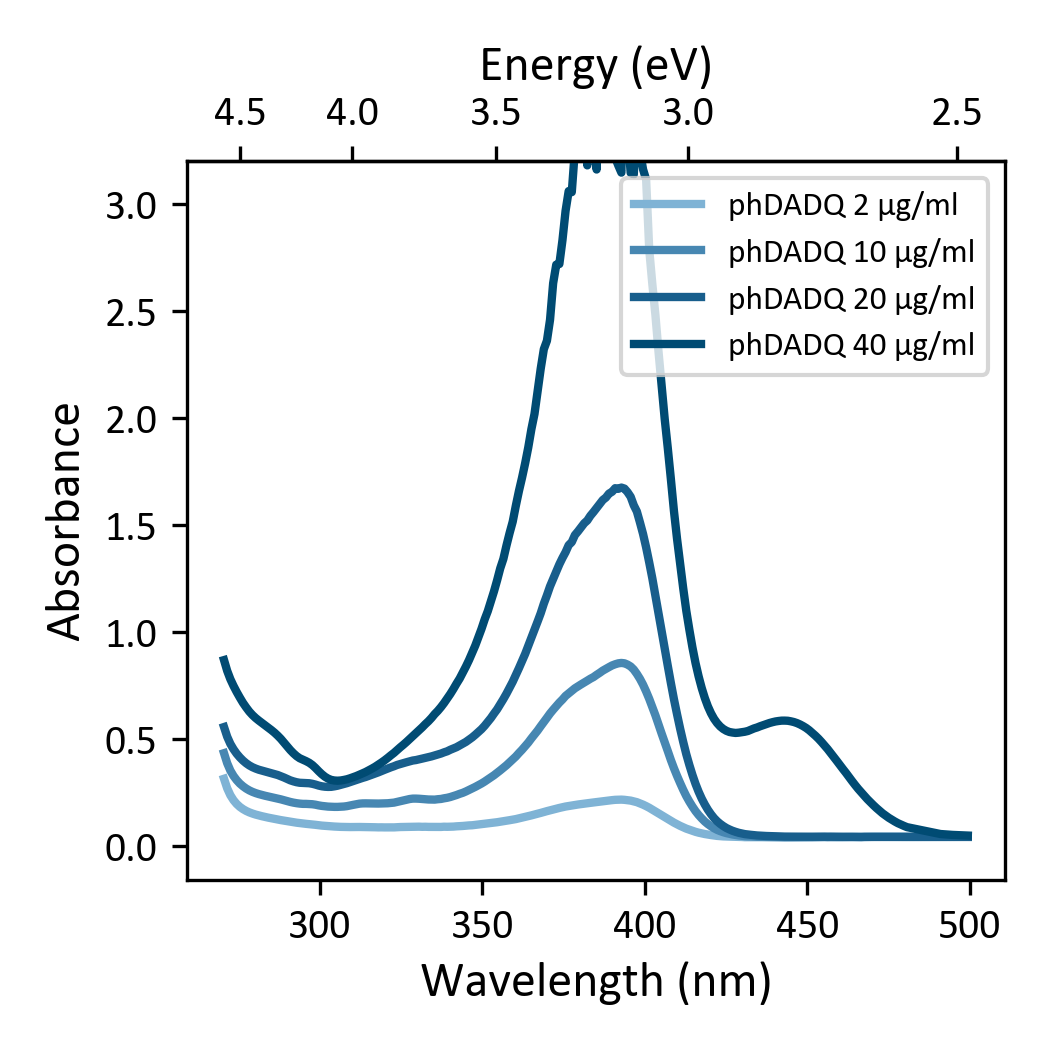

In [10]:
spectra_config = [
    (SphDADQ_DMF_10,  "phDADQ 2 μg/ml",  0.0, "#7FB3D5", "-"),
    #(SphDADQ_DMF_20,  "phDADQ 4 μg/ml",  0.0, "#639DC4", "-"),
    (SphDADQ_DMF_50,  "phDADQ 10 μg/ml",  0.0, "#4787B2", "-"),
    #(SphDADQ_DMF_70,  "phDADQ 14 μg/ml",  0.0, "#2F729F", "-"),
    (SphDADQ_DMF_100, "phDADQ 20 μg/ml", 0.0, "#185E8C", "-"),
    (SphDADQ_DMF_200, "phDADQ 40 μg/ml", 0.0, "#004B73", "-"),
]

SphDADQ_DMF_10
SphDADQ_DMF_20
SphDADQ_DMF_50
SphDADQ_DMF_70
SphDADQ_DMF_100
SphDADQ_DMF_200

# 1. Build Selection using .copy() to protect original objects
SelectionUVvis = []
for var, name, factor, col, ls in spectra_config:
    s = var.copy()  # <-- Crucial: prevents modifying the raw global object in place
    s.N = name
    s.wcorr = factor
    s.color = col
    s.linestyle = ls
    SelectionUVvis.append(s)

# --- PIPELINE DE CORRECCIÓN ---
#Selection = ApplyCalibrationCorrection(Selection, water_calibration) 

# FIX: Use a normalization window that exists in UV-Vis spectra (e.g., 600 to 700 nm)
#SelectionUVvis = NormalizeSpectra(SelectionUVvis, xmin=800, xmax=900, mode="V") 

# Trim to UV-Vis limits (max 1100 nm for these older CSV files)
SelectionUVvis = TrimSpectra(SelectionUVvis, xmin=270, xmax=500)
#Selection = BackgroundCorrection(Selection, a=1, b=0)

poster_style = {
    "figsize": (3.5, 3.5),
    "dpi": 300,
    "font_size": 10,
    "title_size": 12,
    "label_size": 12,
    "legend_size": 8,
    "line_width": 2,
    "font_family": "Calibri",
    "grid": False,               
    "colors": ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#56B4E9", "#D55E00", "#F0E442"], 
    "linestyles": ["-", "--", "-.", ":"]
}


PlotSpectra(
    spectra_list=SelectionUVvis,
    mode="WE",
    offset_step=0.0,
    ymax=3.2,
    ylabel="Absorbance",
    style=poster_style,
    #hide_yticks=True,
    legend_ncol=1
)


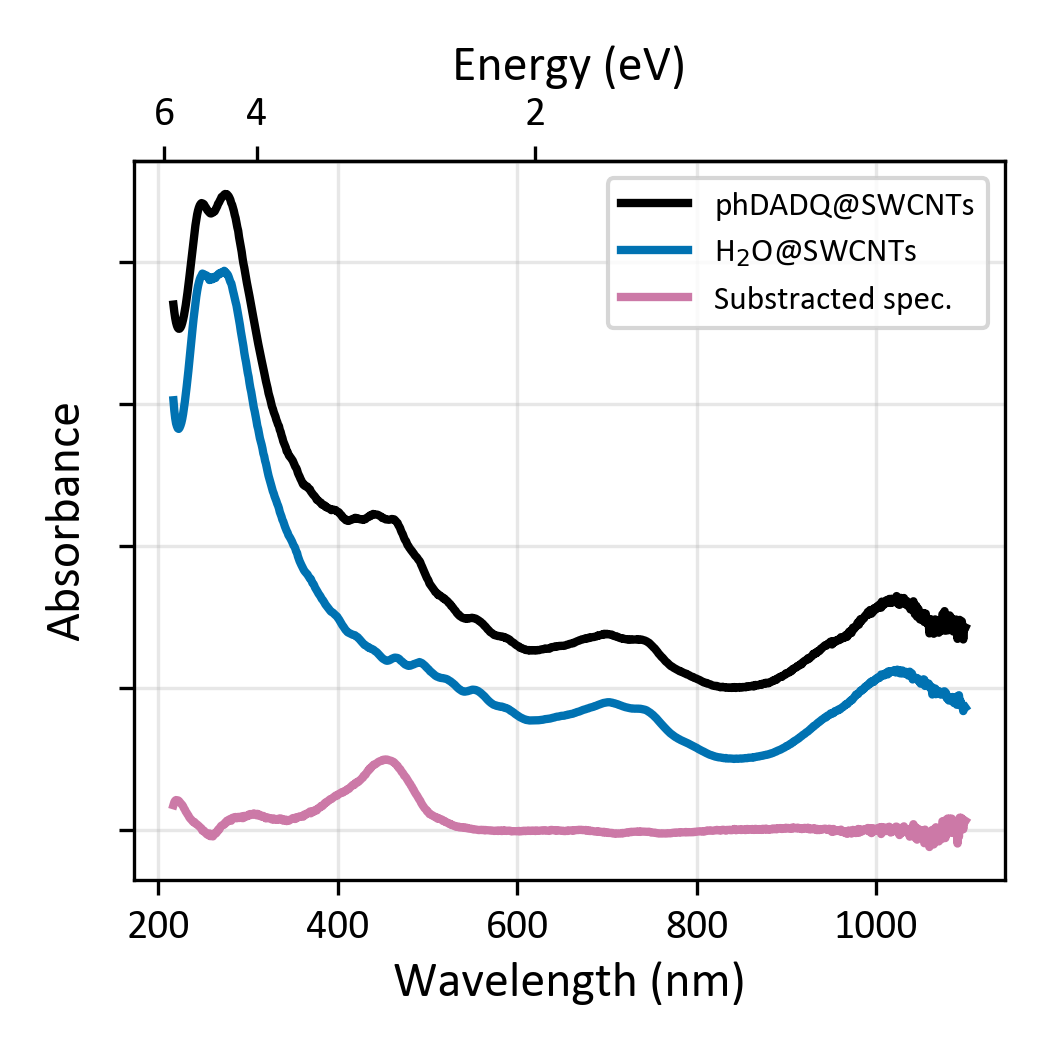

In [11]:
spectra_config = [

    (SF006WA_phDADQ_P2_CF_260605_usedForPLE,     "phDADQ@SWCNTs", 0.0, "#000000", "-"),
    (SP2_SWCNT_CF_usedForPLE,     "H$_2$O@SWCNTs", 0.0, "#0072B2", "-"),

]


# 1. Build Selection using .copy() to protect original objects
SelectionUVvis = []
for var, name, factor, col, ls in spectra_config:
    s = var.copy()  # <-- Crucial: prevents modifying the raw global object in place
    s.N = name
    s.wcorr = factor
    s.color = col
    s.linestyle = ls
    SelectionUVvis.append(s)

# --- PIPELINE DE CORRECCIÓN ---
#Selection = ApplyCalibrationCorrection(Selection, water_calibration) 

# FIX: Use a normalization window that exists in UV-Vis spectra (e.g., 600 to 700 nm)
SelectionUVvis = NormalizeSpectra(SelectionUVvis, xmin=800, xmax=900, mode="V") 

# Trim to UV-Vis limits (max 1100 nm for these older CSV files)
SelectionUVvis = TrimSpectra(SelectionUVvis, xmin=216, xmax=1100)
#Selection = BackgroundCorrection(Selection, a=1, b=0)

if 1==1:
    Substracted = SelectionUVvis[0].copy()
    Substracted.N = "Substracted spec."  # Dale un nombre limpio para la leyenda
    Substracted.color = "#CC79A7"               # Un color distintivo para la resta

    # Restamos los arrays Y
    additionalOffset = -1
    Substracted.Y = SelectionUVvis[0].Y - SelectionUVvis[1].Y - additionalOffset
    #
    # Substracted = TrimSpectra(Substracted, xmin=290, xmax=800)

    # Lo agregamos a la lista que vamos a graficar
    SelectionUVvis.append(Substracted)

# --- GRAFICAR ---
    
poster_style = {
    "figsize": (3.5, 3.5),
    "dpi": 300,
    "font_size": 10,
    "title_size": 12,
    "label_size": 12,
    "legend_size": 8,
    "line_width": 2,
    "font_family": "Calibri",
    "grid": True,               
    "colors": ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#56B4E9", "#D55E00", "#F0E442"], 
    "linestyles": ["-", "--", "-.", ":"]
}



PlotSpectra(
    spectra_list=SelectionUVvis,
    mode="WE",
    offset_step=-0.50,
    #ymax=3.2,
    #xmax=500,
    #xmin=300,
    ylabel="Absorbance",
    style=poster_style,
    #ymax=1,
    hide_yticks=True,
)

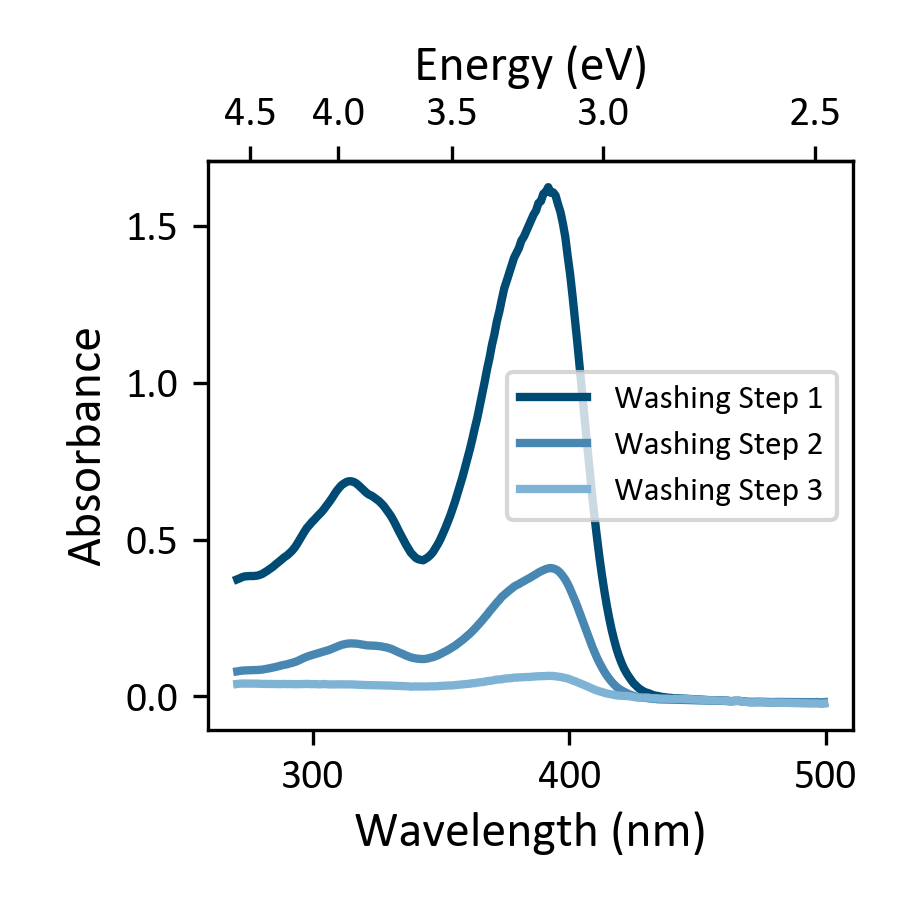

In [13]:
spectra_config = [
    
    (SF006_R0_d20,     "Washing Step 1", 0.0, "#004B73", "-"),
    (SF006_R1_d20,     "Washing Step 2", 0.0, "#4787B2", "-"),
    (SF006_R2_d20,     "Washing Step 3", 0.0, "#7FB3D5", "-"),

]

# 1. Build Selection using .copy() to protect original objects
SelectionUVvis = []
for var, name, factor, col, ls in spectra_config:
    s = var.copy()  # <-- Crucial: prevents modifying the raw global object in place
    s.N = name
    s.wcorr = factor
    s.color = col
    s.linestyle = ls
    SelectionUVvis.append(s)

# --- PIPELINE DE CORRECCIÓN ---
#Selection = ApplyCalibrationCorrection(Selection, water_calibration) 

# FIX: Use a normalization window that exists in UV-Vis spectra (e.g., 600 to 700 nm)
#SelectionUVvis = NormalizeSpectra(SelectionUVvis, xmin=800, xmax=900, mode="V") 

# Trim to UV-Vis limits (max 1100 nm for these older CSV files)
SelectionUVvis = TrimSpectra(SelectionUVvis, xmin=270, xmax=500)
#Selection = BackgroundCorrection(Selection, a=1, b=0)

if 0==1:
    Substracted = SelectionUVvis[0].copy()
    Substracted.N = "Substracted spec."  # Dale un nombre limpio para la leyenda
    Substracted.color = "#CC79A7"               # Un color distintivo para la resta

    # Restamos los arrays Y
    additionalOffset = -1
    Substracted.Y = SelectionUVvis[0].Y - SelectionUVvis[1].Y - additionalOffset
    #
    # Substracted = TrimSpectra(Substracted, xmin=290, xmax=800)

    # Lo agregamos a la lista que vamos a graficar
    SelectionUVvis.append(Substracted)

# --- GRAFICAR ---
    
poster_style = {
    "figsize": (3, 3),
    "dpi": 300,
    "font_size": 10,
    "title_size": 12,
    "label_size": 12,
    "legend_size": 8,
    "line_width": 2,
    "font_family": "Calibri",
    "grid": False,               
    "colors": ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#56B4E9", "#D55E00", "#F0E442"], 
    "linestyles": ["-", "--", "-.", ":"]
}



PlotSpectra(
    spectra_list=SelectionUVvis,
    mode="WE",
    offset_step=-0.00,
    #ymax=3.2,
    #xmax=500,
    #xmin=300,
    ylabel="Absorbance",
    style=poster_style,
    #ymax=1,
    #hide_yticks=True,
)